In [1]:
import cmocean as cm
import dask.distributed as dsk
import glob
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
from dask.distributed import Client
client = Client(threads_per_worker=1, memory_limit=0)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41069,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37271,Total threads: 1
Dashboard: /proxy/45883/status,Memory: 0 B
Nanny: tcp://127.0.0.1:45169,


2026-03-26 12:31:43,490 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('sum-1441fb98df32230ca39f5238bc3343cd', 2, 2, 1, 2) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: <Task ('sum-1441fb98df32230ca39f5238bc3343cd', 2, 2, 1, 2) _execute_subgraph(...)>
new run_spec: <Task ('sum-1441fb98df32230ca39f5238bc3343cd', 2, 2, 1, 2) _execute_subgraph(...)>
old dependencies: {('zeros_like-f9ea2b78a0442ef5d917f5ba379615d1', 2, 2, 1, 2), ('rechunk-merge-9f4c092ff230d12c9b5f17bfd774ad5c', 1, 2), ('getitem-630f6dbca2516ae7af063e3a71ef0020', 2, 2, 1, 2)}
new dependencies: frozenset({('rechunk-merge-9f4c092ff23

In [3]:
import gsw

In [4]:
def preprocess(ds):
    ds = ds[['so', 'volcello']]
    return ds

In [5]:
ds_melt = xr.open_mfdataset(np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-daily-expt-2f759912/output000/*.ocean_daily_z_*.nc')),
                            decode_timedelta=True, preprocess=preprocess, parallel=True, chunks='auto')
ds_melt

<xarray.Dataset> Size: 5GB
Dimensions:   (time: 3, z_l: 75, yh: 845, xh: 3600)
Coordinates:
  * time      (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
  * z_l       (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yh        (yh) float64 7kB -81.11 -81.07 -81.02 ... -37.3 -37.22 -37.14
  * xh        (xh) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Data variables:
    so        (time, z_l, yh, xh) float32 3GB dask.array<chunksize=(1, 33, 363, 1545), meta=np.ndarray>
    volcello  (time, z_l, yh, xh) float32 3GB dask.array<chunksize=(1, 33, 363, 1545), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             panan
    associated_files:  areacello: 20010101.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [6]:
ds_ctrl = xr.open_mfdataset(np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-daily-pan01_test_01-986f8f63/output000/*.ocean_daily_z_*.nc')),
                            decode_timedelta=True, preprocess=preprocess, parallel=True, chunks='auto')
ds_ctrl

<xarray.Dataset> Size: 5GB
Dimensions:   (time: 3, z_l: 75, yh: 845, xh: 3600)
Coordinates:
  * time      (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
  * z_l       (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yh        (yh) float64 7kB -81.11 -81.07 -81.02 ... -37.3 -37.22 -37.14
  * xh        (xh) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Data variables:
    so        (time, z_l, yh, xh) float32 3GB dask.array<chunksize=(1, 33, 363, 1545), meta=np.ndarray>
    volcello  (time, z_l, yh, xh) float32 3GB dask.array<chunksize=(1, 33, 363, 1545), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             panan
    associated_files:  areacello: 20010101.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [7]:
p = gsw.p_from_z(-ds_ctrl['z_l'], ds_ctrl['yh'])

In [8]:
SA_melt = gsw.SA_from_SP(ds_melt['so'], p, ds_ctrl['xh'], ds_ctrl['yh'])
SA_ctrl = gsw.SA_from_SP(ds_ctrl['so'], p, ds_ctrl['xh'], ds_ctrl['yh'])

In [9]:
# Open shelf mask
shelf_mask = xr.open_dataset('/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc')
shelf_mask = shelf_mask['contour_masked_above'].where(shelf_mask['contour_masked_above']==0)

In [10]:
tot_vol_shelf_ctrl = ds_ctrl['volcello'].where(shelf_mask==0).sum(['xh', 'yh', 'z_l']) # m3
tot_vol_shelf_melt = ds_melt['volcello'].where(shelf_mask==0).sum(['xh', 'yh', 'z_l']) # m3

In [11]:
# g/kg * m3 * kg/m3
salt_content_shelf_ctrl = ((SA_ctrl * ds_ctrl['volcello']).where(shelf_mask==0) * 1035).sum(['xh','yh','z_l']) # gr of salt on the shelf
salt_content_shelf_melt = ((SA_melt * ds_melt['volcello']).where(shelf_mask==0) * 1035).sum(['xh','yh','z_l']) # gr of salt on the shelf

In [12]:
salinity_changes = salt_content_shelf_melt/tot_vol_shelf_melt - salt_content_shelf_ctrl/tot_vol_shelf_ctrl

salinity_changes_vol_only = salt_content_shelf_ctrl/tot_vol_shelf_melt - salt_content_shelf_ctrl/tot_vol_shelf_ctrl

salinity_changes_salt_only = salt_content_shelf_melt/tot_vol_shelf_ctrl - salt_content_shelf_ctrl/tot_vol_shelf_ctrl

In [13]:
salinity_changes = salinity_changes.load()
salinity_changes_vol_only = salinity_changes_vol_only.load()
salinity_changes_salt_only = salinity_changes_salt_only.load()

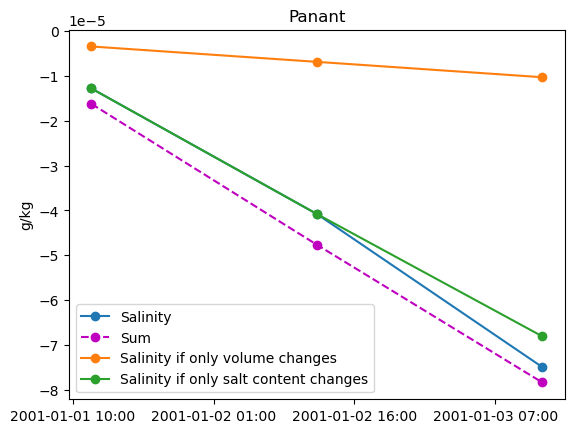

In [14]:
(salinity_changes/1035).plot(label='Salinity', marker='o')
((salinity_changes_salt_only+salinity_changes_vol_only)/1035).plot(c='m', linestyle='--', label='Sum', marker='o')
(salinity_changes_vol_only/1035).plot(label='Salinity if only volume changes', marker='o')
(salinity_changes_salt_only/1035).plot(label='Salinity if only salt content changes', marker='o')
plt.legend()
plt.xlabel(''); plt.ylabel('g/kg'); plt.title('Panant');

The decomposition is not exact.

In [15]:
((salinity_changes_salt_only+salinity_changes_vol_only)/1035 - salinity_changes/1035)

<xarray.DataArray (time: 3)> Size: 24B
array([-3.42885504e-06, -6.85743490e-06, -3.42862050e-06])
Coordinates:
  * time     (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
Attributes:
    time_avg_info:  average_T1,average_T2,average_DT
    units:          m3
    long_name:      Ocean grid-cell volume
    cell_methods:   area:sum z_l:sum yh:sum xh:sum time: mean
    cell_measures:  area: areacello
    standard_name:  ocean_volume

Katja's decomposition:

In [16]:
salinity_changes = salt_content_shelf_melt/tot_vol_shelf_melt - salt_content_shelf_ctrl/tot_vol_shelf_ctrl

salinity_changes_1 = salt_content_shelf_melt/tot_vol_shelf_melt - salt_content_shelf_ctrl/tot_vol_shelf_melt

salinity_changes_2 = salt_content_shelf_ctrl/tot_vol_shelf_melt - salt_content_shelf_ctrl/tot_vol_shelf_ctrl

In [17]:
salinity_changes = salinity_changes.load()
salinity_changes_1 = salinity_changes_1.load()
salinity_changes_2 = salinity_changes_2.load()

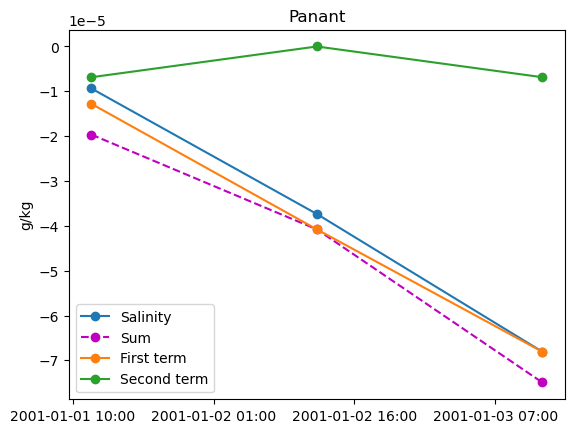

In [18]:
(salinity_changes/1035).plot(label='Salinity', marker='o')
((salinity_changes_2+salinity_changes_1)/1035).plot(c='m', linestyle='--', label='Sum', marker='o')
(salinity_changes_1/1035).plot(label='First term', marker='o')
(salinity_changes_2/1035).plot(label='Second term', marker='o')
plt.legend()
plt.xlabel(''); plt.ylabel('g/kg'); plt.title('Panant');